<a href="https://colab.research.google.com/github/munizgui/CP2_SEM2_SERS/blob/main/1CCA_ML_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exemplo de treinamento e avaliação de um modelo preditivo de classificação

# Preparação do ambiente


In [36]:
import pandas as pd

# Ferramentas para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Separação de dados de treinamento e teste
from sklearn.model_selection import train_test_split

# Algoritmos para classificação:
# Regressão logística
from sklearn.linear_model import LogisticRegression
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Avaliação dos modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Carga dos dados

In [37]:
# Adicionar o github para que ele nao fique puxando aqui, e sim todos os arquivos lá
dados = pd.read_csv('http://raw.githubusercontent.com/munizgui/CP2_SEM2_SERS/refs/heads/main/csv/Data_for_UCI_named.csv')

# Análise exploratória

In [38]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [39]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [40]:
# Estastísticas de colunas categóricas
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [41]:
# Lista das categorias/classes da coluna alvo
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [42]:
# COntagem das categorias da coluna 'stabf' (coluna alvo --> target)
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [43]:
# Definição de dados de entrada (Features/Variaveis Independentes)
# E dados de saida (Target/Variável Dependente)
# X (maiúsculo) ---> entrada
# y (minúsculo) ---> saída

In [44]:
X = dados.drop(columns=['stab', 'stabf'])
y = dados['stabf']

In [45]:
type(X)

pandas.core.frame.DataFrame

In [46]:
X

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391


In [47]:
type(y)

pandas.core.series.Series

In [48]:
y

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable
...,...
9995,unstable
9996,stable
9997,stable
9998,unstable


# Separação de dados de treinamento e teste

X_train,X_test, y_train, y_test

In [49]:
# SEED ---> random_state ---> parâmetro para "fixar" a amostra
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [50]:
# Instanciado o primeiro (LogisticRegression)
modelo_LR = LogisticRegression()

In [51]:
# Treinamento do modelo
modelo_LR.fit(X_train, y_train)

LogisticRegression()

In [52]:
# Geração de probabilidades
probabilidades = modelo_LR.predict_proba(X_test)
probabilidades[:50]

array([[0.03825818, 0.96174182],
       [0.18760004, 0.81239996],
       [0.85964922, 0.14035078],
       [0.8889158 , 0.1110842 ],
       [0.02299536, 0.97700464],
       [0.9086316 , 0.0913684 ],
       [0.07714869, 0.92285131],
       [0.10140089, 0.89859911],
       [0.19258966, 0.80741034],
       [0.92089189, 0.07910811],
       [0.02648338, 0.97351662],
       [0.96382519, 0.03617481],
       [0.17703937, 0.82296063],
       [0.84515051, 0.15484949],
       [0.05981379, 0.94018621],
       [0.30590534, 0.69409466],
       [0.42881637, 0.57118363],
       [0.02138358, 0.97861642],
       [0.77277877, 0.22722123],
       [0.38408291, 0.61591709],
       [0.25730871, 0.74269129],
       [0.21253236, 0.78746764],
       [0.01101105, 0.98898895],
       [0.55511496, 0.44488504],
       [0.5941227 , 0.4058773 ],
       [0.03729827, 0.96270173],
       [0.03018877, 0.96981123],
       [0.81818048, 0.18181952],
       [0.08051674, 0.91948326],
       [0.21380298, 0.78619702],
       [0.

In [53]:
# Geração de previsões
y_predict = modelo_LR.predict(X_test)
y_predict[:50]

array(['unstable', 'unstable', 'stable', 'stable', 'unstable', 'stable',
       'unstable', 'unstable', 'unstable', 'stable', 'unstable', 'stable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'stable', 'unstable', 'unstable', 'stable',
       'unstable', 'unstable', 'unstable', 'unstable', 'unstable',
       'stable', 'unstable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable',
       'unstable', 'stable', 'unstable', 'unstable', 'unstable', 'stable',
       'unstable'], dtype=object)

In [54]:
# Avaliação do modelo
'''
Gerar comandos para as métricas do modelo treinado usando seaborn e matplotlib.
Crie gráficos auxiliares e tabelas contendo todas as métricas que importamos na celula inicial.
Incluindo classification report.
'''

'\nGerar comandos para as métricas do modelo treinado usando seaborn e matplotlib.\nCrie gráficos auxiliares e tabelas contendo todas as métricas que importamos na celula inicial.\nIncluindo classification report.\n'

### Novo Exercício: Predição de Regressão Linear para a variável 'stab'
Primeiro, vamos gerar a matriz de correlação das variáveis numéricas para identificar quais possuem maior correlação linear com a nossa variável alvo `stab`.

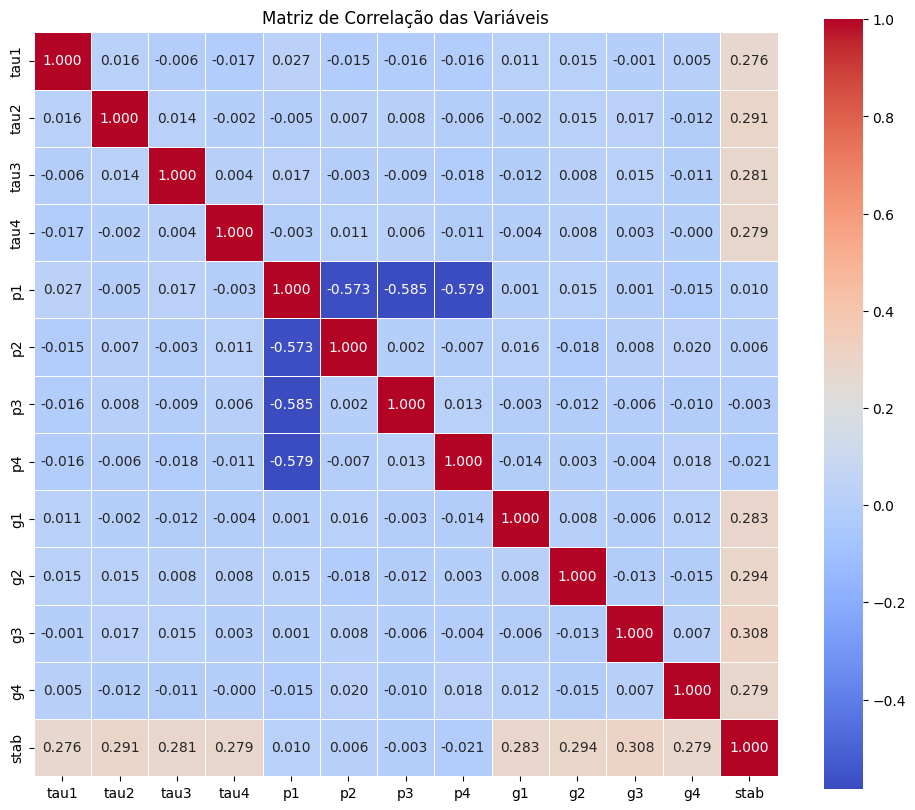

In [55]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Selecionando apenas as colunas numéricas (excluindo 'stabf' que é categórica)
colunas_numericas = dados.select_dtypes(include=[np.number])
correlacao = colunas_numericas.corr()

# Criando o Heatmap de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlacao, annot=True, fmt='.3f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

Agora, vamos analisar a correlação direta de todas as variáveis com a nossa variável alvo `stab` para selecionar as melhores *features* para o modelo de Regressão Linear.

In [56]:
# Correlação das features com a variável alvo 'stab'
corr_com_stab = correlacao['stab'].sort_values(ascending=False)
print("Correlação das variáveis com 'stab':")
print(corr_com_stab)

Correlação das variáveis com 'stab':
stab    1.000000
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p1      0.010278
p2      0.006255
p3     -0.003321
p4     -0.020786
Name: stab, dtype: float64


Com base na correlação obtida, as variáveis mais correlacionadas linearmente com `stab` (sejam correlações positivas ou negativas) são os tempos de resposta `tau1`, `tau2`, `tau3` e `tau4` (e os coeficientes `g1`, `g2`, `g3`, `g4`). Já as potências `p1`, `p2`, `p3` e `p4` têm correlação quase nula com a estabilidade.

Vamos selecionar as principais features (por exemplo, `tau1`, `tau2`, `tau3`, `tau4`, `g1`, `g2`, `g3`, `g4`) para criar o nosso modelo preditivo.

Gerando gráficos de correlação...


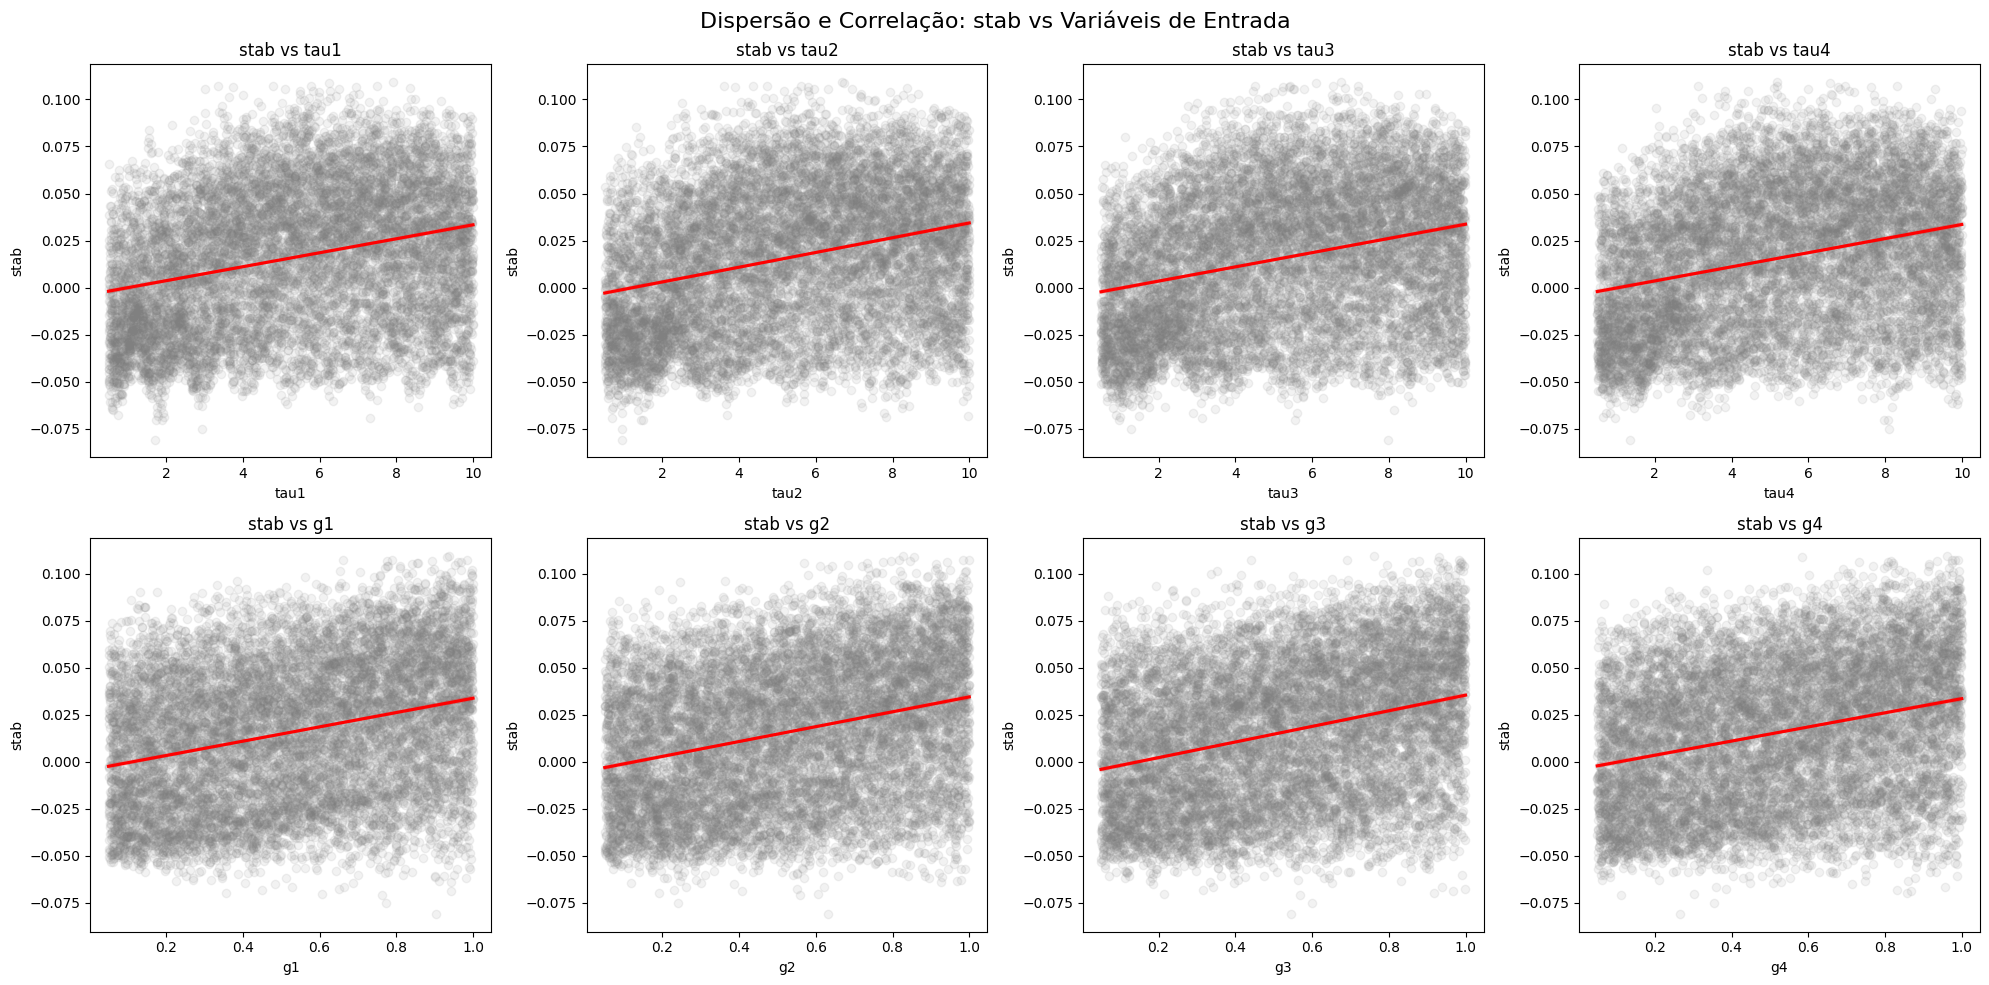

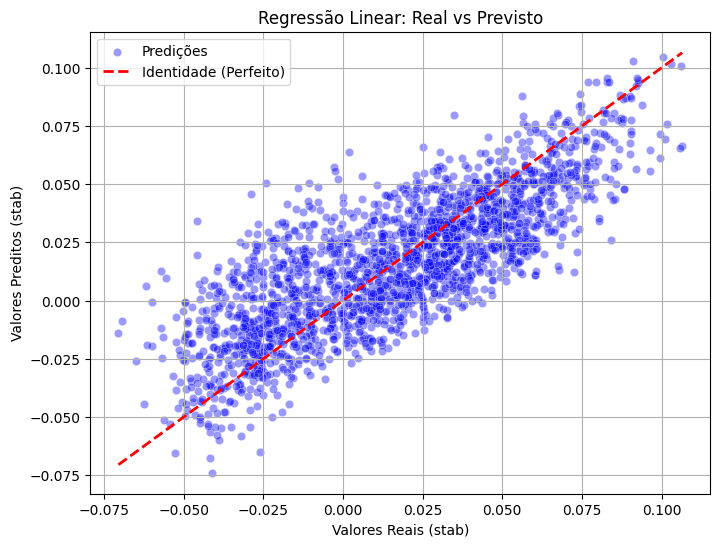

Erro Quadrático Médio (MSE): 0.000481
Coeficiente de Determinação (R²): 0.629805


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definição de X (features com maior correlação) e y (target)
features_selecionadas = ['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']
X_reg = dados[features_selecionadas]
y_reg = dados['stab']

# 2. Separação em treino e teste
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=1)

# 3. Treinamento do modelo de Regressão Linear
modelo_linear = LinearRegression()
modelo_linear.fit(X_train_reg, y_train_reg)

# 4. Predições
y_pred_reg = modelo_linear.predict(X_test_reg)

# --- GRÁFICOS DE CORRELAÇÃO (stab vs variáveis de entrada) ---
print("Gerando gráficos de correlação...")
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Dispersão e Correlação: stab vs Variáveis de Entrada", fontsize=16)

for i, col in enumerate(features_selecionadas):
    row_idx = i // 4
    col_idx = i % 4
    sns.regplot(x=dados[col], y=dados['stab'], ax=axes[row_idx, col_idx],
                scatter_kws={'alpha':0.1, 'color': 'gray'}, line_kws={'color': 'red'})
    axes[row_idx, col_idx].set_title(f'stab vs {col}')
    axes[row_idx, col_idx].set_xlabel(col)
    axes[row_idx, col_idx].set_ylabel('stab')

plt.tight_layout()
plt.show()

# --- GRÁFICO REAL X PREVISTO ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.4, color='blue', label='Predições')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Identidade (Perfeito)')
plt.xlabel('Valores Reais (stab)')
plt.ylabel('Valores Preditos (stab)')
plt.title('Regressão Linear: Real vs Previsto')
plt.legend()
plt.grid(True)
plt.show()

# Métricas adicionais de exibição
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"Erro Quadrático Médio (MSE): {mse:.6f}")
print(f"Coeficiente de Determinação (R²): {r2:.6f}")

Por fim, vamos fazer as predições no conjunto de teste e avaliar a performance do modelo de Regressão Linear utilizando métricas apropriadas para regressão (R² e MSE).

Erro Quadrático Médio (MSE): 0.000481
Coeficiente de Determinação (R²): 0.629805


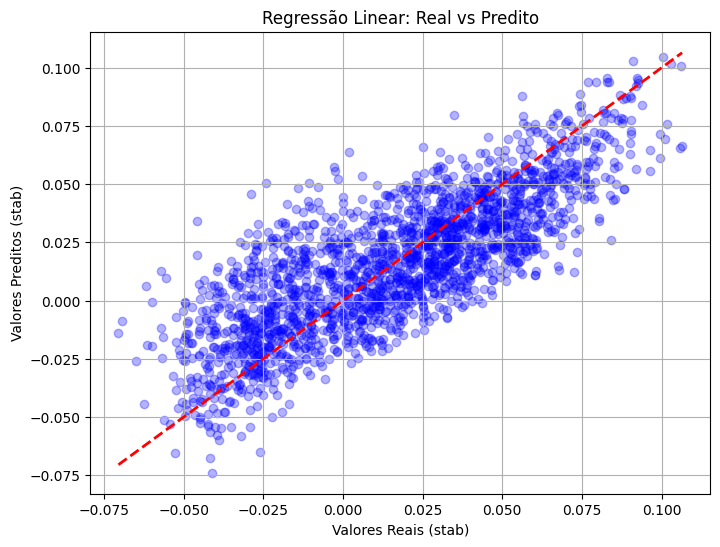

In [58]:
# Predições
y_pred_reg = modelo_linear.predict(X_test_reg)

# Métricas de Avaliação
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Erro Quadrático Médio (MSE): {mse:.6f}")
print(f"Coeficiente de Determinação (R²): {r2:.6f}")

# Gráfico de dispersão de Real vs Predito
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Valores Reais (stab)')
plt.ylabel('Valores Preditos (stab)')
plt.title('Regressão Linear: Real vs Predito')
plt.grid(True)
plt.show()